## Trabajo en clase 03: Interpolación

**Nombre completo: Efrain Rojas Garcia**

**Carné: C36883**

### Fecha de entrega
Jueves 17 de setiembre de 2026, 23:59 h.

### Instrucciones generales
Lea los enunciados de los siguientes dos ejercicios, **complete el código** faltante y **responda a las preguntas planteadas**.

### Formato de entrega
Guarde el notebook en una carpeta llamanda `03-Trabajo_en_clase` y subir a su repositorio privado en GitHub.

## Interpolación de Lagrange

El objetivo de este ejercicio es aproximar una función conocida mediante un **polinomio interpolante de Lagrange** y estudiar cómo cambia la aproximación al aumentar el número de nodos.

Considere la función

$$
f(x) = (1-2x^2)\sin\left(\frac{5\pi x}{2}\right),
\qquad -1\leq x\leq 1.
$$

Utilizaremos polinomios interpolantes de grados

$$
n\in\{4,8,12,16\}.
$$

Para construir un polinomio de grado $n$ se utilizarán $n+1$ nodos equiespaciados en el intervalo $[-1,1]$.

### 1. Implementación de la función (10 puntos)

Defina una función en Python:

- `f(x)`: devuelve el valor de

$$
f(x) = (1-2x^2)\sin\left(\frac{5\pi x}{2}\right).
$$

La función debe poder recibir tanto un único valor de $x$ como un arreglo de NumPy.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de la función
def f(x):
    '''
    TODO:
    Complete aquí la definición de la función.
    '''
    func= (1-2*x**2)*np.sin((5*np.pi*x)/2)
    
    return func

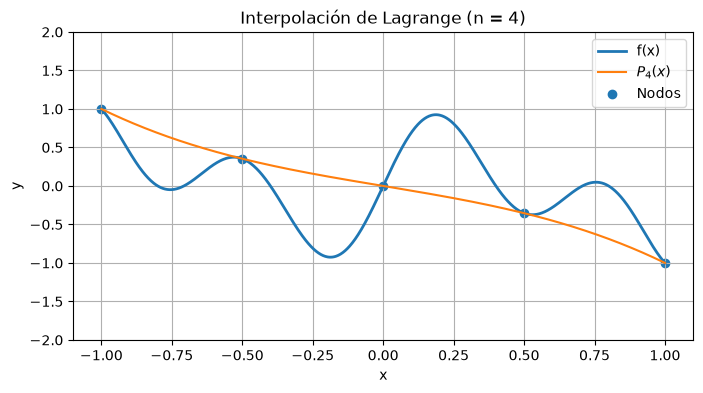

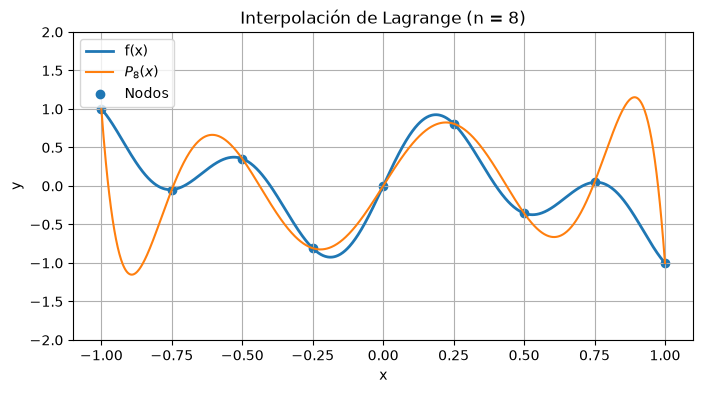

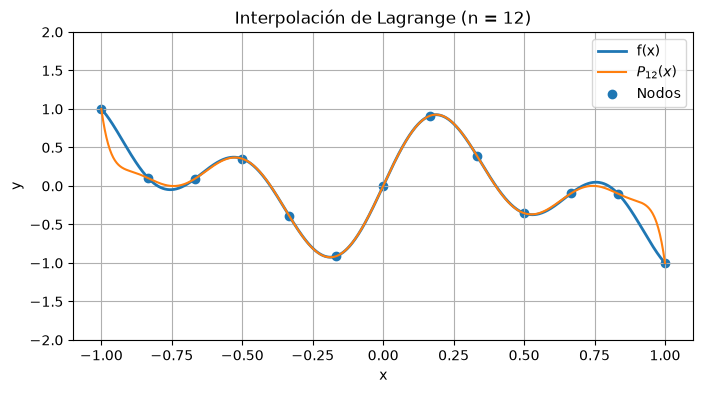

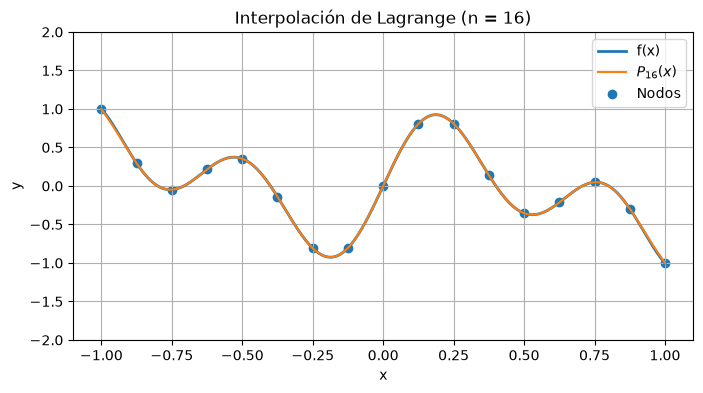

### 2. Implementación del polinomio interpolante de Lagrange (30 puntos)

Dados $n+1$ nodos

$$
x_0,x_1,\ldots,x_n
$$

y los valores de la función en esos nodos

$$
f_i=f(x_i),
$$

el polinomio interpolante de Lagrange está dado por

$$
P_n(x)=\sum_{i=0}^{n} f_i\,\ell_i(x),
$$

donde los polinomios base de Lagrange son

$$
\ell_i(x)
=
\prod_{\substack{j=0\\j\neq i}}^{n}
\frac{x-x_j}{x_i-x_j}.
$$

Implemente la función:

- `lagrange_interpolacion(x_nodes, y_nodes, x)`

donde:

- `x_nodes` contiene las posiciones de los nodos $x_i$,
- `y_nodes` contiene los valores $f(x_i)$,
- `x` contiene los puntos donde se desea evaluar el polinomio interpolante.

Implemente directamente la expresión matemática anterior utilizando ciclos `for`. No utilice funciones de interpolación disponibles en NumPy, SciPy u otras bibliotecas.

In [4]:
def lagrange_interpolacion(x_nodes, y_nodes, x):
    '''
    TODO:
    Implemente aquí el polinomio interpolante de Lagrange.

    Sugerencia:
    1. Convierta x en un arreglo de NumPy.
    2. Inicialice P(x) con ceros.
    3. Para cada nodo i, construya el polinomio base L_i(x).
    4. Acumule y_nodes[i] * L_i(x) en P(x).
    '''
    x= np.array(x)
    Pol=np.zeros_like(x)
    n=len(x_nodes)
    
    for i in range(n):
        L_i=np.ones_like(x)
        
        for j in range(n):
            if i != j:
                L_i *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        
        Pol += y_nodes[i] * L_i
        
    return Pol
    

### 3. Construcción de la malla y los nodos (10 puntos)

Para comparar la función original con los polinomios interpolantes:

1. Construya una malla uniforme de **1000 puntos** en el intervalo $[-1,1]$. Esta malla se utilizará únicamente para evaluar y visualizar las funciones.
2. Evalúe $f(x)$ sobre esta malla.
3. Considere los grados

$$
n\in\{4,8,12,16\}.
$$

Para cada valor de $n$:

1. Construya $n+1$ nodos equiespaciados en $[-1,1]$.
2. Evalúe la función $f(x)$ en esos nodos.
3. Evalúe el polinomio interpolante $P_n(x)$ sobre la malla fina.

In [5]:
# Malla fina para evaluar y graficar
x_fina = np.linspace(-1,1,1000)
y_exacta = f(x_fina)

# Grados de los polinomios interpolantes
valores_n = [4, 8, 12, 16]

for n in valores_n:

    # Construcción de los n+1 nodos
    x_nodes = np.linspace(-1, 1, n + 1)

    # Evaluación de f(x) en los nodos
    y_nodes = f(x_nodes)

    # Evaluación del polinomio interpolante en la malla fina
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

    '''
    TODO:
    Reemplace los valores None por las expresiones o
    llamadas a funciones correspondientes.
    '''

### 4. Visualización de resultados (10 puntos)

Para cada valor de $n$, genere una figura que muestre:

- la función original $f(x)$ mediante una línea continua,
- el polinomio interpolante $P_n(x)$,
- los $n+1$ nodos de interpolación $(x_i,f_i)$ mediante puntos.

Compare visualmente cómo cambia la aproximación al aumentar el grado $n$.

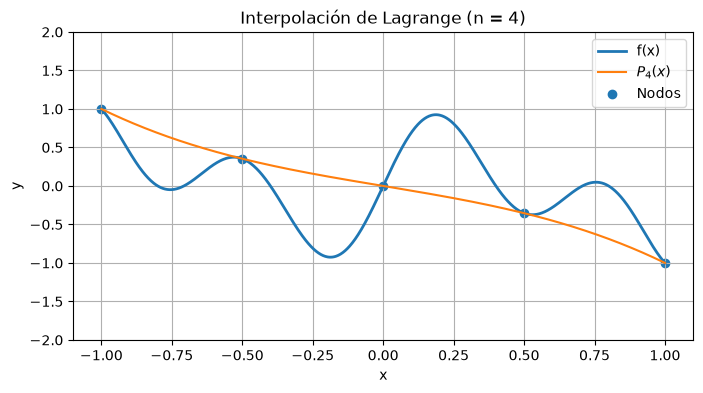

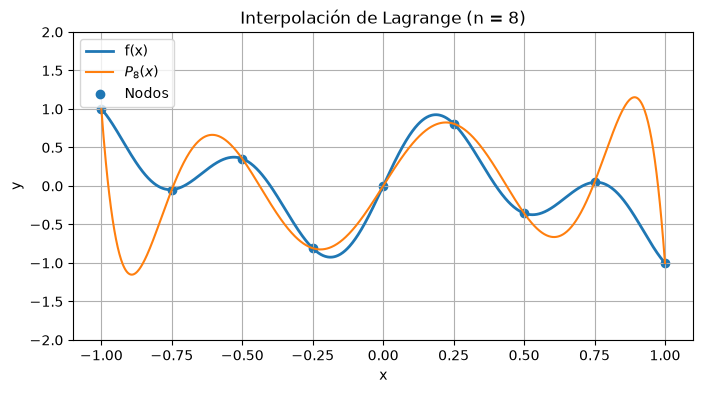

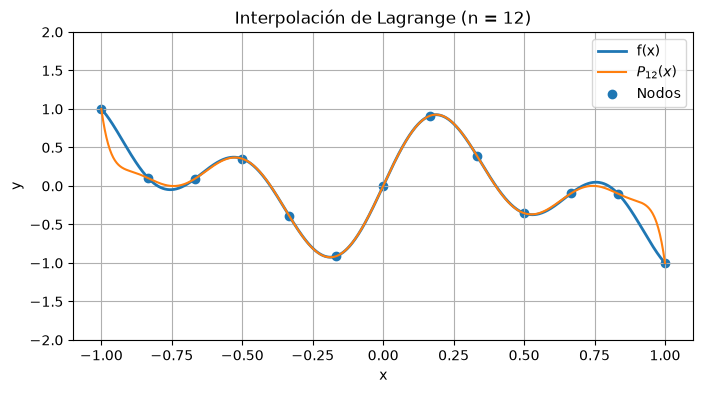

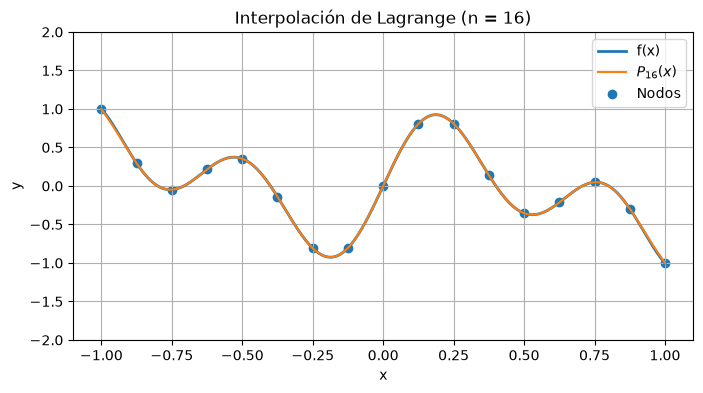

In [6]:
# Malla fina para evaluar y graficar
x_fina = np.linspace(-1, 1, 1000)
y_exacta = f(x_fina)

valores_n = [4, 8, 12, 16]

for n in valores_n:

    # Construcción de los nodos
    '''
    TODO:
    Construya n+1 nodos equiespaciados y evalúe f(x)
    en cada uno de ellos.
    '''
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)

    # Interpolación
    '''
    TODO:
    Evalúe el polinomio interpolante sobre x_fina.
    '''
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

    # Gráfica de comparación
    plt.figure(figsize=(8, 4))
    plt.plot(x_fina, y_exacta, label='f(x)', linewidth=2)
    plt.plot(x_fina, y_interp, label=f'$P_{{{n}}}(x)$')
    plt.scatter(x_nodes, y_nodes, label='Nodos')

    plt.title(f'Interpolación de Lagrange (n = {n})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.ylim(-2, 2)
    plt.legend()
    plt.grid(True)
    plt.show()

### 5. Análisis del error (20 puntos)

Para cuantificar la calidad de la interpolación, calcule el error absoluto sobre la malla fina:

$$
E(x)=|P_n(x)-f(x)|.
$$

Para cada valor de $n$:

1. Calcule el error absoluto en los 1000 puntos de la malla.
2. Determine el error máximo:

$$
E_{\max}=\max_x |P_n(x)-f(x)|.
$$

3. Imprima el error máximo obtenido para cada valor de $n$.
4. Grafique el error absoluto en función de $x$.

Observe tanto el valor del error como las regiones del intervalo donde este es mayor.

n = 4: error máximo = 1.045185e+00


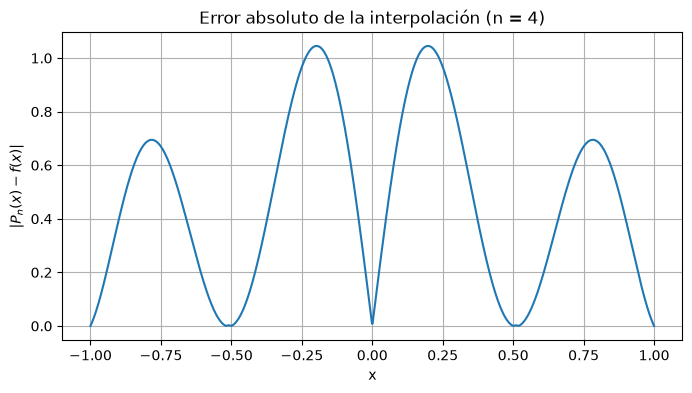

n = 8: error máximo = 1.615090e+00


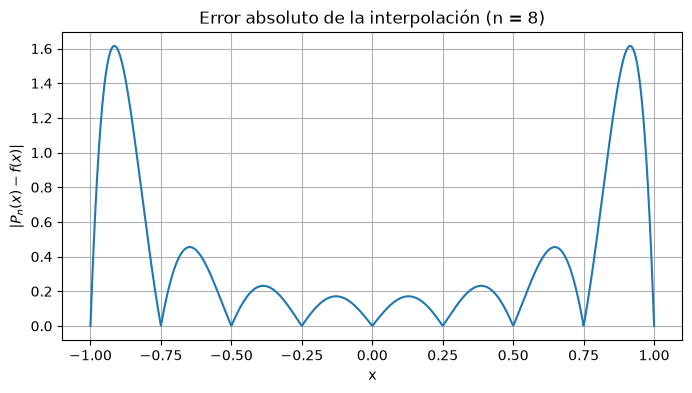

n = 12: error máximo = 4.231757e-01


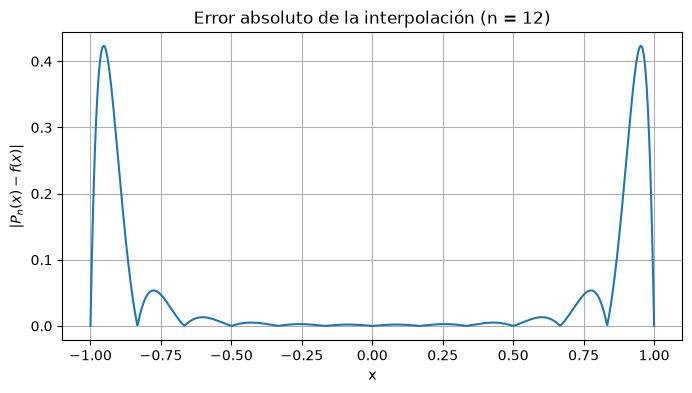

n = 16: error máximo = 1.669883e-02


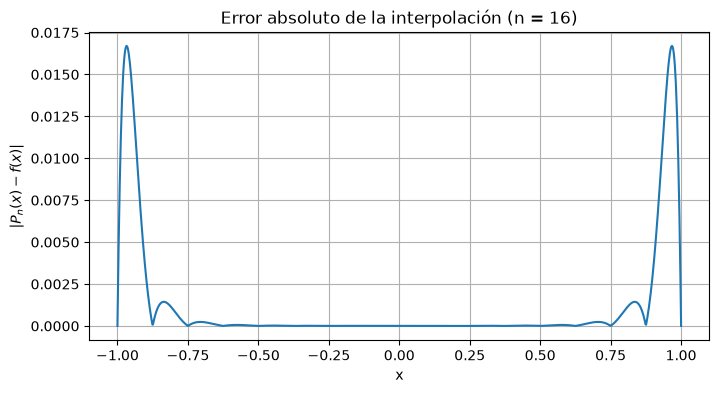

In [10]:
for n in valores_n:

    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

    # Cálculo del error
    '''
    TODO:
    Calcule el error absoluto y el error máximo.
    '''
    error = np.abs(y_interp - y_exacta)
    error_maximo = np.max(error)

    print(f"n = {n}: error máximo = {error_maximo:.6e}")

    # Gráfica del error absoluto
    plt.figure(figsize=(8, 4))
    plt.plot(x_fina, error)
    plt.title(f'Error absoluto de la interpolación (n = {n})')
    plt.xlabel('x')
    plt.ylabel(r'$|P_n(x)-f(x)|$')
    plt.grid(True)
    plt.show()

### 6. Fenómeno de Runge (10 puntos)

Repita el procedimiento anterior utilizando ahora la función

$$
f(x)=\frac{1}{1+25x^2},
\qquad -1\leq x\leq1.
$$

Para ello, modifique únicamente la definición de `f(x)` y vuelva a ejecutar las celdas correspondientes a la interpolación, las gráficas y el análisis del error.

Utilice nuevamente

$$
n\in\{4,8,12,16\}
$$

y nodos equiespaciados en $[-1,1]$.

Observe cuidadosamente qué ocurre cerca de los extremos del intervalo cuando aumenta el grado del polinomio interpolante.

In [17]:
# Nueva función para estudiar el fenómeno de Runge
def func(x):
    '''
    TODO:
    Implemente aquí

                1
    f(x) = ------------
            1 + 25 x^2
    '''
    
    f= 1/(1+25*x**2)
    
    return f


In [18]:
# Malla fina para evaluar y graficar
x_fina = np.linspace(-1,1,1000)
y_exacta = func(x_fina)

# Grados de los polinomios interpolantes
valores_n = [4, 8, 12, 16]

for n in valores_n:

    # Construcción de los n+1 nodos
    x_nodes = np.linspace(-1, 1, n + 1)

    # Evaluación de f(x) en los nodos
    y_nodes = func(x_nodes)

    # Evaluación del polinomio interpolante en la malla fina
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

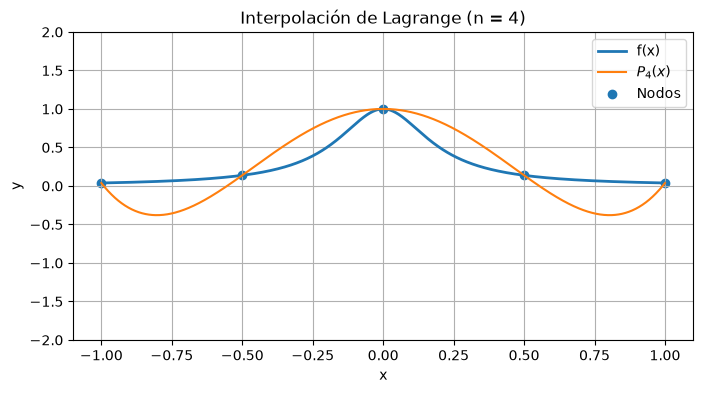

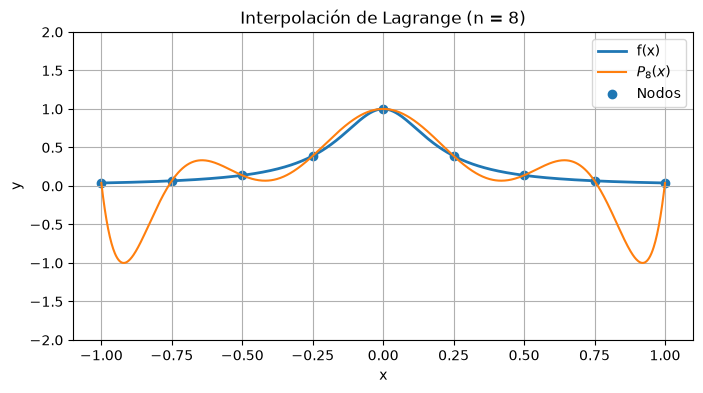

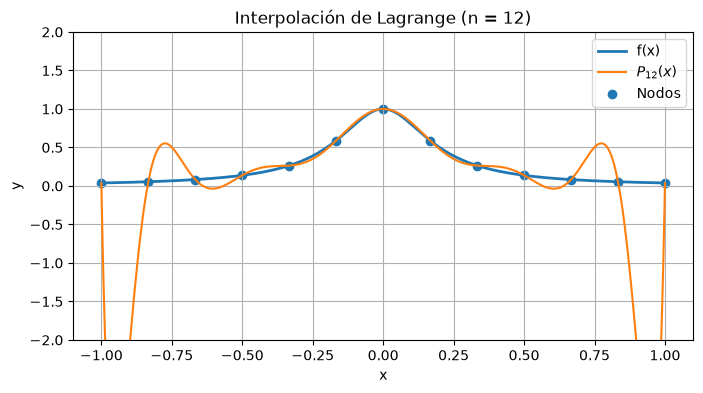

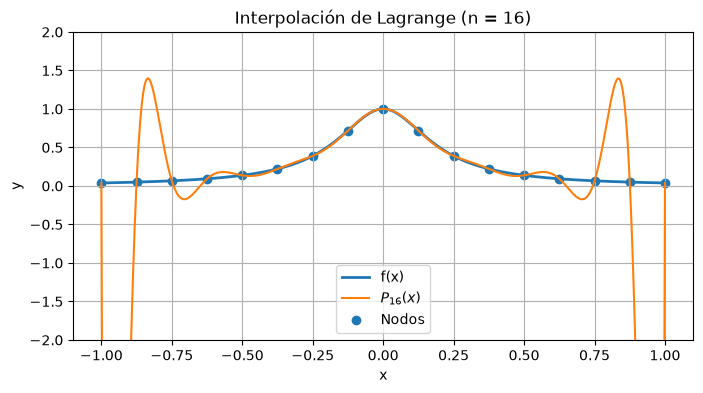

In [19]:
# Malla fina para evaluar y graficar
x_fina = np.linspace(-1, 1, 1000)
y_exacta = func(x_fina)

valores_n = [4, 8, 12, 16]

for n in valores_n:

    # Construcción de los nodos
    '''
    TODO:
    Construya n+1 nodos equiespaciados y evalúe f(x)
    en cada uno de ellos.
    '''
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = func(x_nodes)

    # Interpolación
    '''
    TODO:
    Evalúe el polinomio interpolante sobre x_fina.
    '''
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

    # Gráfica de comparación
    plt.figure(figsize=(8, 4))
    plt.plot(x_fina, y_exacta, label='f(x)', linewidth=2)
    plt.plot(x_fina, y_interp, label=f'$P_{{{n}}}(x)$')
    plt.scatter(x_nodes, y_nodes, label='Nodos')

    plt.title(f'Interpolación de Lagrange (n = {n})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.ylim(-2, 2)
    plt.legend()
    plt.grid(True)
    plt.show()

n = 4: error máximo = 1.038462e+00


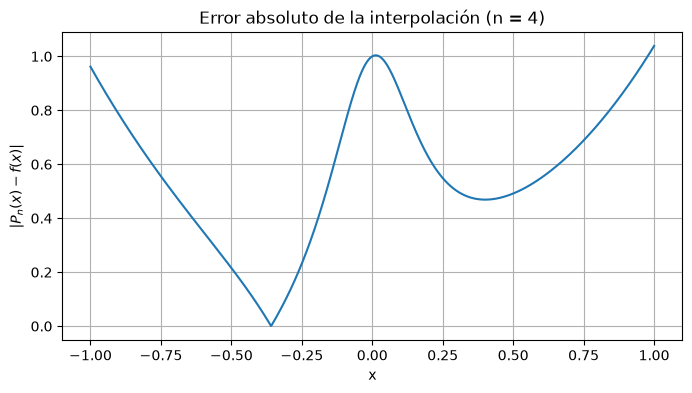

n = 8: error máximo = 1.358026e+00


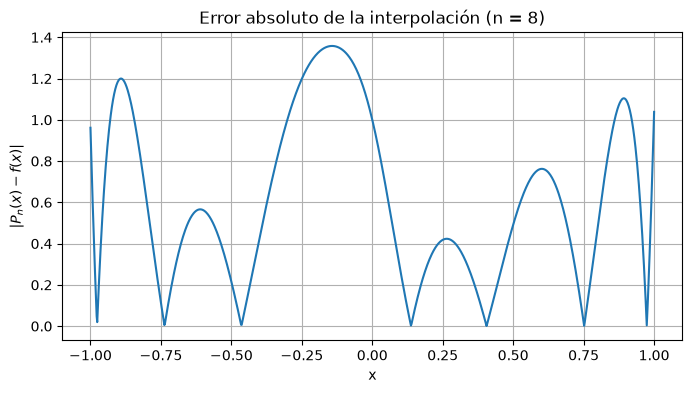

n = 12: error máximo = 1.526485e+00


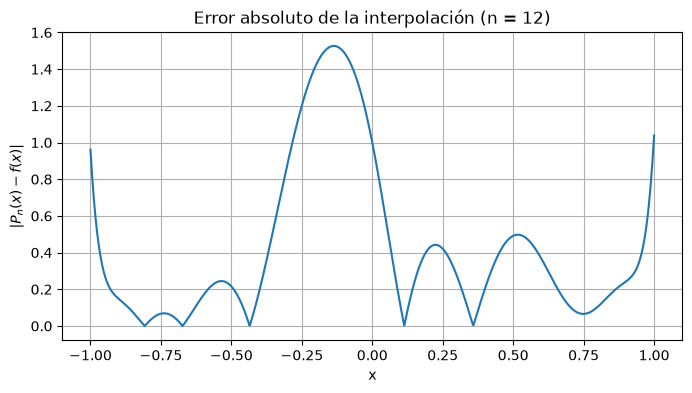

n = 16: error máximo = 1.527690e+00


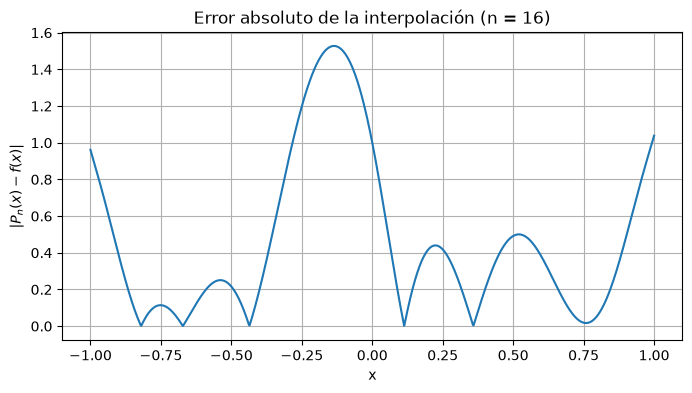

In [20]:
for n in valores_n:

    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)
    y_interp = lagrange_interpolacion(x_nodes, y_nodes, x_fina)

    # Cálculo del error
    '''
    TODO:
    Calcule el error absoluto y el error máximo.
    '''
    error = np.abs(y_interp - y_exacta)
    error_maximo = np.max(error)

    print(f"n = {n}: error máximo = {error_maximo:.6e}")

    # Gráfica del error absoluto
    plt.figure(figsize=(8, 4))
    plt.plot(x_fina, error)
    plt.title(f'Error absoluto de la interpolación (n = {n})')
    plt.xlabel('x')
    plt.ylabel(r'$|P_n(x)-f(x)|$')
    plt.grid(True)
    plt.show()

### 7. Discusión (20 puntos)

Responda brevemente:

1. Para la función original, ¿cómo cambia la aproximación al aumentar el grado $n$ del polinomio?

2. ¿En qué regiones del intervalo se observa el mayor error de interpolación? Utilice las gráficas de error para justificar su respuesta.

3. Al utilizar

$$
f(x)=\frac{1}{1+25x^2},
$$

¿mejora la interpolación en todo el intervalo al aumentar $n$? Describa lo que observa.

4. ¿En qué regiones aparecen las mayores diferencias entre la función y el polinomio interpolante para esta segunda función?

5. Investigue y explique brevemente qué es el **fenómeno de Runge**. Relacione su explicación con los resultados obtenidos en este ejercicio.

In [ ]:
1. al aumentar el grado de n, el polinomio se aproxima cada vez mejor a la función original, esto es que en n=2 y n=16, en n=2 se aproxima claramente de mejor forma.

2. Se muestra mayor error en los extremo, x=-1 y x=1, en cambio a la region central se aprecia mejor el siguimiento a la función original.

3. Lo que sucede con esta función es que al aumentar los nodos puede hacer que la aproximación empeore, ya que aparecen mayores oscilaciones en los extremos.

4.en los extremos, x=-+1 

5.El fenómeno de Runge explica que al agregar nodos equisespaciodos se esperaria que la aproximación mejor, pero sucede que se muestran mas oscilaciones en los extremos, emperoando la aproximacion.
